In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns

### Feature Scaling types:
#### Standardization (Z-Score Normalization)

Standardization is a feature scaling technique also known as **Z-score normalization**. It transforms data so that the feature has:

* **Mean = 0**
* **Standard Deviation = 1**

##### Formula

$$
x' = \frac{x_i - \mu}{\sigma}
$$

Where:

* $ x_i $ = original value
* $ \mu $ = mean of the feature
* $ \sigma $ = standard deviation of the feature
* $ x' $ = standardized value

---

##### What Happens After Standardization?

After transformation:

* The **mean of the feature becomes 0**
* The **standard deviation becomes 1**
* The feature values are centered around zero
* The distribution shape remains the same (only scale changes)

Standardization does **not** restrict values between 0 and 1. Values can be negative or greater than 1 depending on their distance from the mean.

---

## Geometric Intuition (How It Works)
'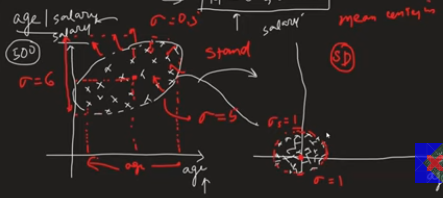'
Imagine a 2D dataset:

* X-axis → Age
* Y-axis → Salary

Suppose:

* Mean of Age = 40
* Standard deviation of Age = 5
* Mean of Salary = 50,000
* Standard deviation of Salary = 10,000

Standardization performs two operations:

### 1. Mean Centering

We subtract the mean from each value.
This shifts the entire dataset so that its center moves to **(0,0)**.

### 2. Scaling by Standard Deviation

We divide by the standard deviation.
This compresses or stretches the data so that its spread becomes standardized.

Geometrically:

* The data cloud shifts to the origin.
* Both axes are rescaled so that one unit represents one standard deviation.
* The relative distances between points remain proportional.

---

## Why Standardization Is Important

Standardization is essential for algorithms that are sensitive to feature magnitude, such as:

* K-Nearest Neighbors (KNN)
* Support Vector Machines (SVM)
* Logistic Regression
* Gradient Descent-based models
* Principal Component Analysis (PCA)

Without standardization, features with larger numeric ranges dominate distance calculations and optimization processes.


In [5]:
df = pd.read_csv(r"C:\Users\QC\Downloads\Social_Network_Ads.csv")

In [8]:
df=df.iloc[:,2:]

In [9]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [10]:
## Train and test split
## you can do normalization and standardization without trian test split but it is recoomanded to do it
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),
                                                    df['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((280, 2), (120, 2))

In [11]:
## standard scaler 
## it is do the sme work wht we discuss that it subtract values form mean and we can make our own class
## data only learn form trainig set and scale both triannig and testing set
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
scaler.mean_  ##it is the mean of age and salary

array([3.78642857e+01, 6.98071429e+04])

In [13]:
X_train

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [15]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [16]:
X_train_scaled

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [17]:
np.round(X_train.describe(), 1)


,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [18]:
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


##### <b>Effect of Scaling </b>

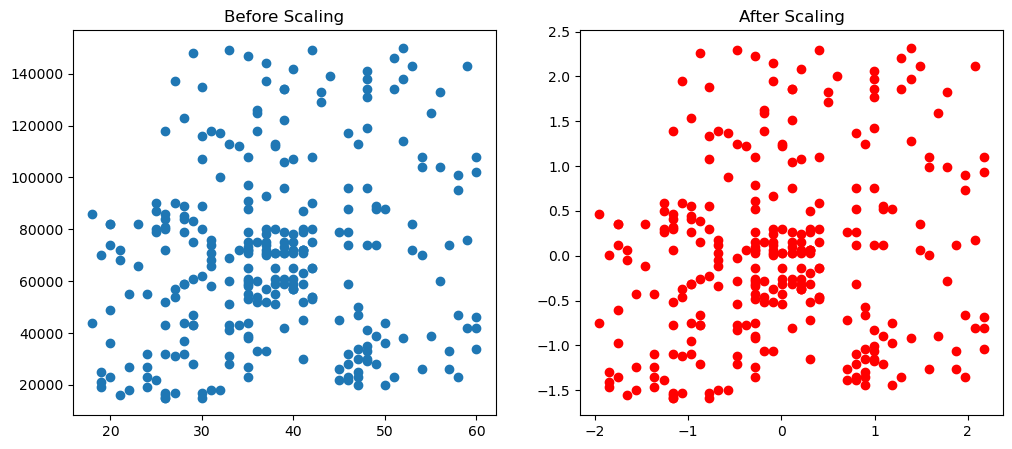

In [19]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

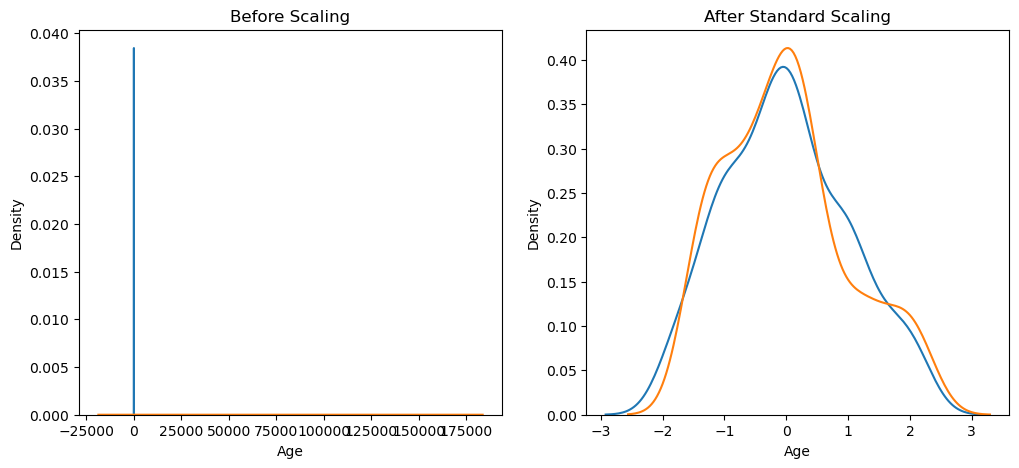

In [21]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

#### Comparison of Distributions
- No change in shapes only change in scale

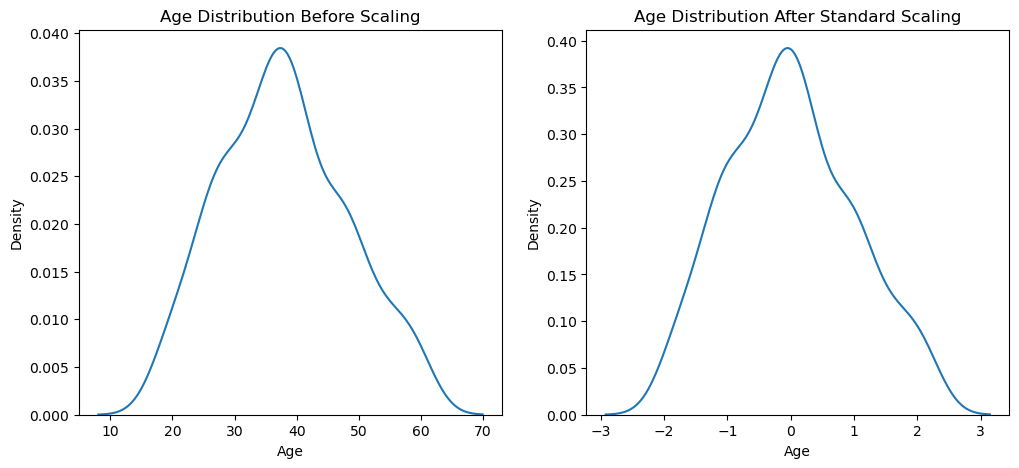

In [22]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)

# after scaling
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
plt.show()

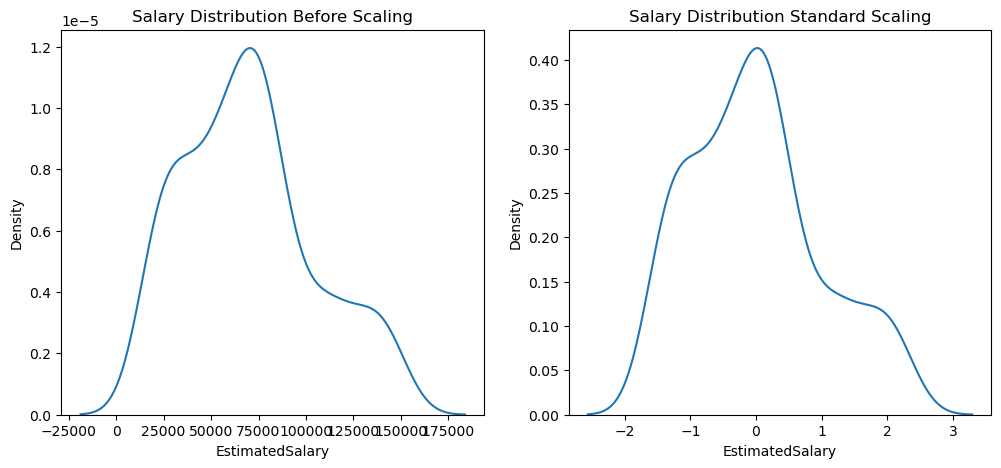

In [23]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Salary Distribution Before Scaling')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('Salary Distribution Standard Scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

#### Why scaling is important?

In [30]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [31]:
lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [32]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [33]:
from sklearn.metrics import accuracy_score
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))
##there is a difference before and after scaling, the one moe important thing is on decision tree there is no difference before and afre scaling means accuracy will be same

Actual 0.875
Scaled 0.8666666666666667


## Effect of Outlier
- the outlier does not reduce or remove by scaling we seen below

In [36]:
new_rows = pd.DataFrame({
    'Age': [5, 90, 95],
    'EstimatedSalary': [1000, 250000, 350000],
    'Purchased': [0, 1, 1]
})

df = pd.concat([df, new_rows], ignore_index=True)


In [37]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


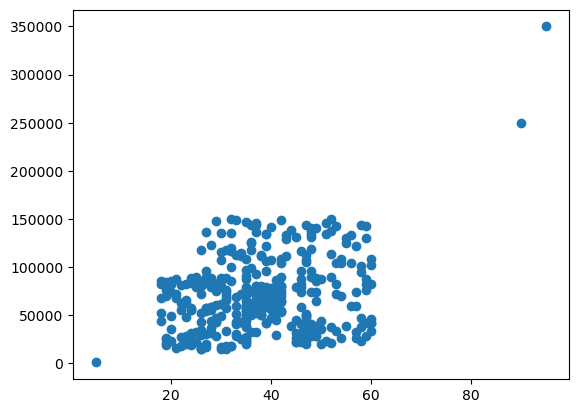

In [38]:
plt.scatter(df['Age'], df['EstimatedSalary'])

In [40]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),
                                                    df['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((282, 2), (121, 2))

In [41]:
scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

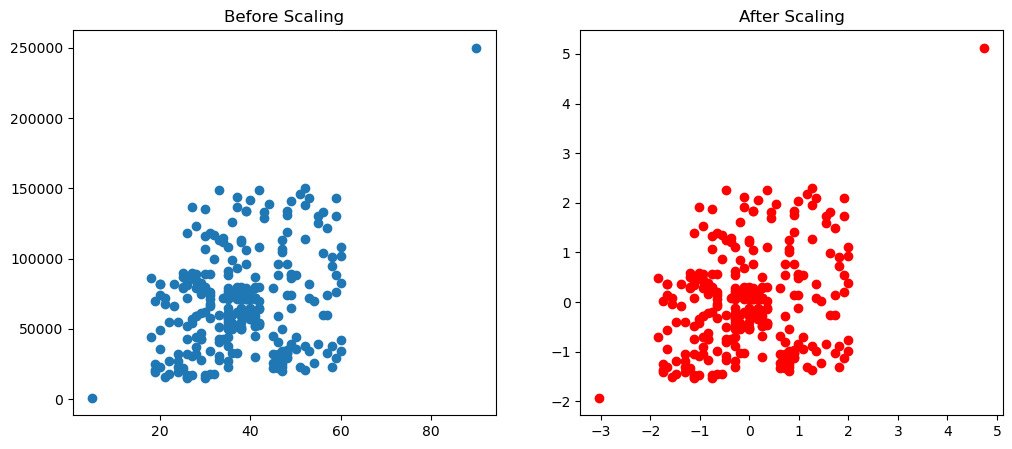

In [43]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

## no difference outlier still an outlier


# Normalization

Normalization is a feature scaling technique used in data preprocessing to bring numeric features onto a common scale without distorting the relationships between values. It is especially useful when features have different ranges.

Unlike standardization, normalization typically rescales data into a **fixed range**, most commonly **[0, 1]**.

---

# Types of Normalization

## 1. Min-Max Scaling (Most Common)

### Formula

$$
x' = \frac{x_i - x_{\min}}{x_{\max} - x_{\min}}
$$

Where:

- $x_i$ = original value  
- $x_{\min}$ = minimum value of the feature  
- $x_{\max}$ = maximum value of the feature  

### Resulting Range

- Values are transformed into the range **[0, 1]**
- Can also scale to any custom range like [-1, 1]

### Geometric Intuition
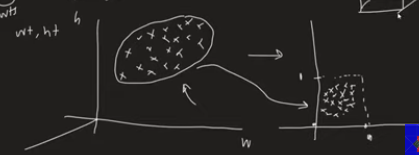
Imagine a 2D graph:

- X-axis → Height  
- Y-axis → Weight  

Min-max scaling compresses all data points into a **unit square (0 to 1 range)**.

- In 2D → points fit inside a square  
- In 3D → points fit inside a cube  
- In higher dimensions → points fit inside a hypercube  

However, min-max scaling is **sensitive to outliers** because it depends directly on minimum and maximum values.

---

## 2. Mean Normalization

### Formula

$$
x' = \frac{x_i - \mu}{x_{\max} - x_{\min}}
$$

Where:

- $\mu$ = mean of the feature

### Resulting Range

Usually falls between **[-1, 1]**

- If value > mean → positive  
- If value < mean → negative  

It is rarely used in practice. Standardization is generally preferred because it uses standard deviation instead of range and is statistically more stable.

---

## 3. Max Absolute Scaling

### Formula

$$
x' = \frac{x_i}{|x_{\max}|}
$$

### Key Characteristics

- Scales values to range **[-1, 1]**
- Does not shift/center the data
- Preserves sparsity
- Used mainly for sparse datasets (e.g., text data, TF-IDF matrices)

---

## 4. Robust Scaling

Robust scaling uses:

- Median instead of mean
- Interquartile Range (IQR) instead of standard deviation

### Formula

$$
x' = \frac{x_i - \text{median}}{IQR}
$$

Where:

$$
IQR = Q3 - Q1
$$

### Advantage

- Robust to outliers
- Not affected by extreme values
- Used when dataset contains significant outliers

---

# Normalization vs Standardization

## Is Feature Scaling Required?

Feature scaling is required when:

- Using distance-based algorithms (KNN, K-Means)
- Using gradient descent optimization
- Features have very different ranges

Not required for:

- Tree-based models (Decision Tree, Random Forest)

---

## When to Use Standardization vs Normalization?

### Standardization (Z-score)

- Mean = 0  
- Standard Deviation = 1  
- Works well in most ML problems  
- Less sensitive to outliers than Min-Max  
- Preferred default choice  

### Normalization (Min-Max)

- Scales to fixed range [0,1]
- Useful when:
  - You know the data bounds
  - Input range matters (e.g., pixel values 0–255 in CNNs)
  - Neural networks with bounded activation functions
```

In [46]:
df = pd.read_csv(r'C:\Users\QC\Downloads\wine_data.csv',header=None,usecols=[0,1,2])
df.columns=['Class label', 'Alcohol', 'Malic acid']

In [47]:
df.head()

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

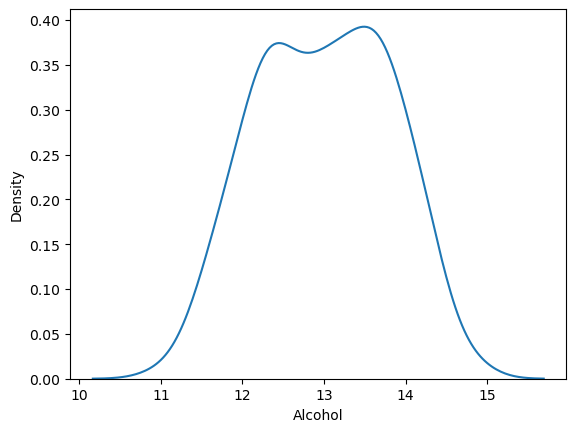

In [48]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

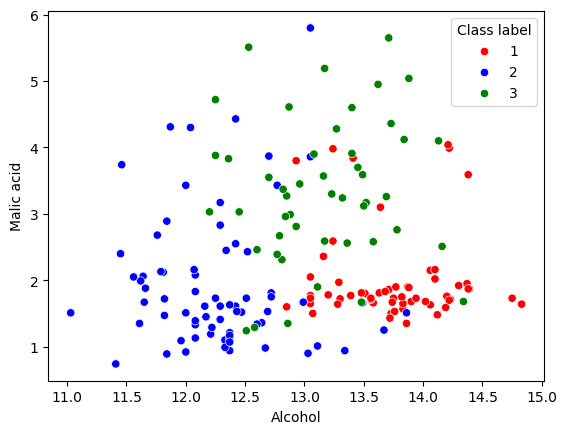

In [50]:
color_dict={1:'red',3:'green',2:'blue'}
sns.scatterplot(x='Alcohol',y='Malic acid',hue='Class label',palette=color_dict,data=df)

In [51]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('Class label', axis=1),
                                                    df['Class label'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((124, 2), (54, 2))

In [53]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train) ## find the ninimum and maximum value

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [54]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [55]:
np.round(X_train.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [56]:
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


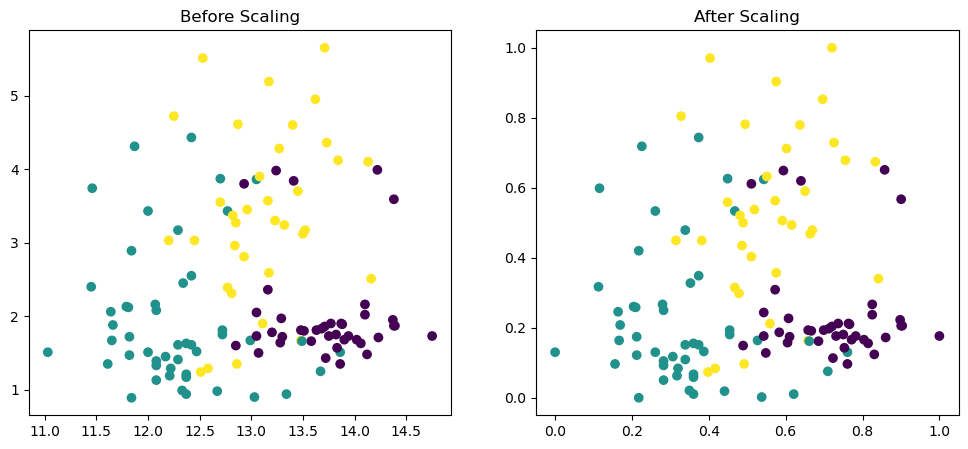

In [57]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Alcohol'], X_train['Malic acid'],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'],c=y_train)
ax2.set_title("After Scaling")
plt.show()

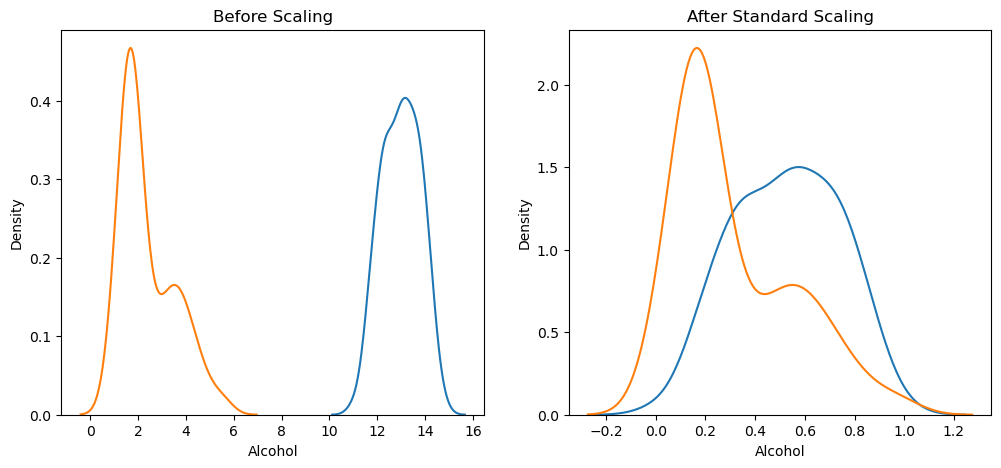

In [58]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()

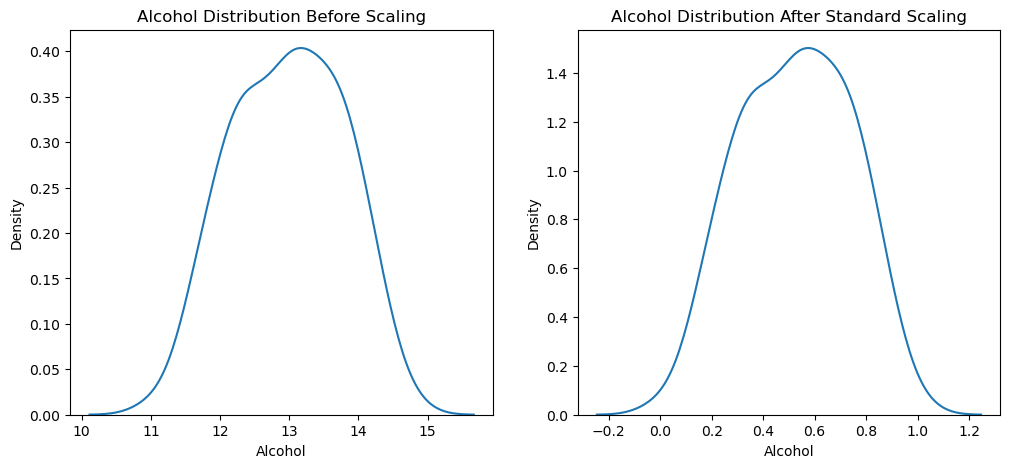

In [59]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
plt.show()

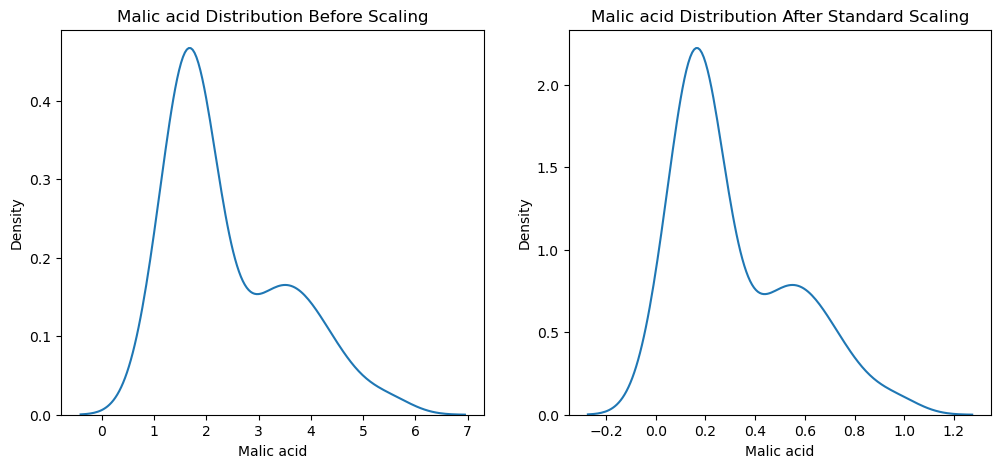

In [60]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('Malic acid Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()

## it might be possible their distributiion change but min and max distribution  will be same
## drawback:switch oultier